# Credit Card Customer Churn - EDA

## Objectives

- Explore the cleaned credit card customer dataset.
- Analyse customer demographics, financial characteristics, and behavioural patterns.
- Compare existing and churned customers.
- Identify key factors associated with customer churn.
- Generate insights and visualisations to support the machine learning stage.

## Inputs

- `data/processed/bank_churners_clean.csv`
## Outputs

- Exploratory analysis of customer churn.
- Visualisations showing important churn patterns and relationships.
- Key insights to support feature selection and machine learning.

## Additional Comments

- This notebook uses the cleaned dataset generated in `01_ETL.ipynb`.
- Data cleaning and preparation are not repeated in this notebook.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\credit-card-customer-churn-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\credit-card-customer-churn-analysis'

# Section 1. Setting the Scene


Before exploring customer churn, the following statistical concepts provide the foundation for the analysis:

- **Mean and Median:** Measures of central tendency used to summarise typical customer behaviour. The median is particularly useful when data contains outliers.

- **Standard Deviation:** Measures how much values vary around the mean and helps identify variability in customer behaviour.

- **Probability:** Represents the likelihood of an event occurring. In this project, it relates to the likelihood of customer churn.

- **Hypothesis Testing:** Used to assess whether observed relationships or differences are statistically meaningful. The null hypothesis (H0) assumes no significant relationship, while the alternative hypothesis (H1) assumes a significant relationship.

These concepts support the exploratory and statistical analysis conducted in the following sections.


---

# Section 2. Quick Dataset Overview

This section provides a quick overview of the cleaned dataset before conducting the main exploratory analysis.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/processed/bank_churners_clean.csv")

df.head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [5]:
print(f"Dataset shape: {df.shape}")
print("\nDataset information:")
df.info()

Dataset shape: (10127, 21)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal    

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


---

# Section 3. Churn Overview

This section examines the overall distribution of customer churn to understand the balance between existing and attrited customers.

In [8]:
df["Churn"].value_counts()

Churn
0    8500
1    1627
Name: count, dtype: int64

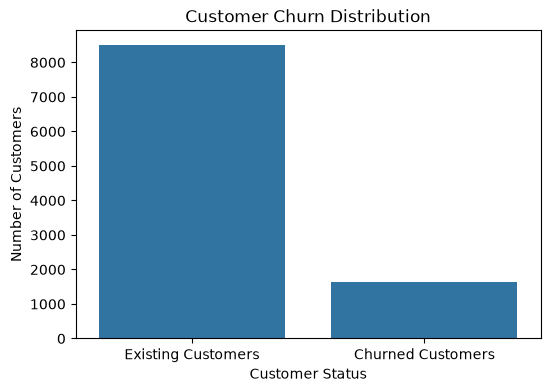

In [10]:
churn_counts = df["Churn"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Existing Customers", "Churned Customers"],
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()


---

## Section 4. Hypothesis Exploration

- Customer Inactivity and Churn
- Transaction Frequency and Churn
- Transaction Amount and Churn
- Credit Utilisation and Churn

### Hypothesis 1 — Customer Inactivity and Churn

**Business Question:**  
Are customers with longer periods of inactivity more likely to churn?

**Feature:** `Months_Inactive_12_mon`

**Null Hypothesis (H0):**  
There is no significant difference in customer inactivity between existing and churned customers.

**Alternative Hypothesis (H1):**  
Churned customers have significantly higher levels of inactivity than existing customers.

In [11]:
df.groupby("Churn")["Months_Inactive_12_mon"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,8500.0,2.273765,1.016741,0.0,1.0,2.0,3.0,6.0
1,1627.0,2.693301,0.899623,0.0,2.0,3.0,3.0,6.0


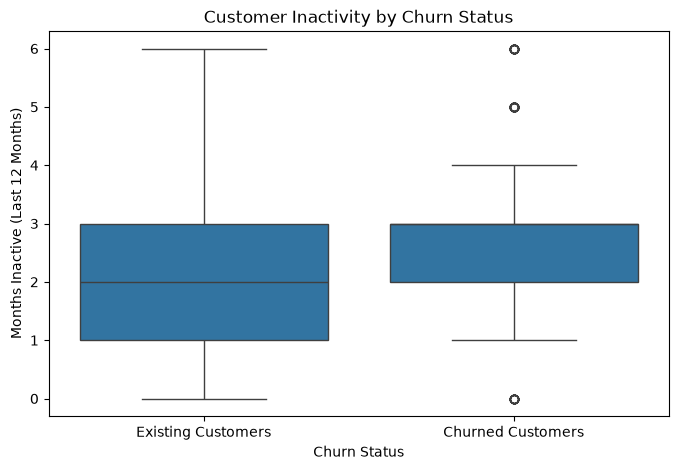

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Months_Inactive_12_mon"
)

plt.title("Customer Inactivity by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Months Inactive (Last 12 Months)")
plt.xticks([0, 1], ["Existing Customers", "Churned Customers"])

plt.show()


In [13]:

from scipy.stats import ttest_ind

existing = df[df["Churn"] == 0]["Months_Inactive_12_mon"]
churned = df[df["Churn"] == 1]["Months_Inactive_12_mon"]

t_stat, p_value = ttest_ind(churned, existing, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")


T-statistic: 16.862
P-value: 0.00000


#### Hypothesis 1. Outcome

The statistical test produced a p-value below 0.05, indicating a statistically significant difference in inactivity between existing and churned customers.

Churned customers had a higher average number of inactive months than existing customers.

**Outcome:** The null hypothesis (H0) is rejected. The results support the alternative hypothesis (H1).

**Business Implication:** Customer inactivity may be an important indicator of churn risk. The bank could monitor customers with increasing periods of inactivity and consider targeted retention strategies.

### Hypothesis 2 — Transaction Frequency and Churn

**Business Question:**  
Are customers with lower transaction frequency more likely to churn?

**Feature:** `Total_Trans_Ct`

**Null Hypothesis (H0):**  
There is no significant difference in transaction frequency between existing and churned customers.

**Alternative Hypothesis (H1):**  
Churned customers have significantly lower transaction frequency than existing customers.


In [14]:
df.groupby("Churn")["Total_Trans_Ct"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,8500.0,68.672588,22.919011,11.0,54.0,71.0,82.0,139.0
1,1627.0,44.933620,14.568429,10.0,37.0,43.0,51.0,94.0


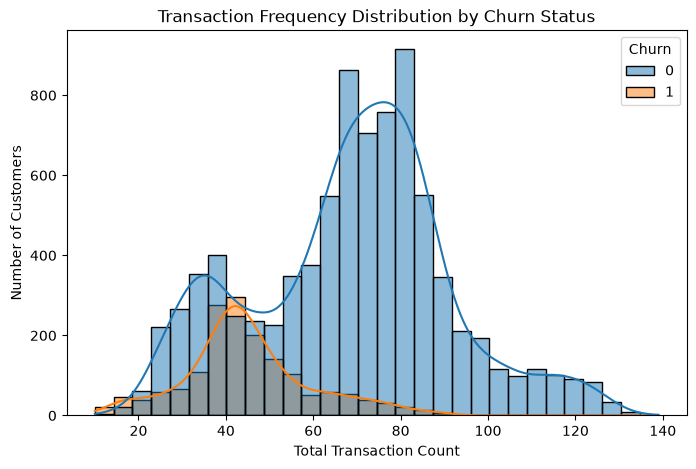

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Total_Trans_Ct",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Transaction Frequency Distribution by Churn Status")
plt.xlabel("Total Transaction Count")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
existing = df[df["Churn"] == 0]["Total_Trans_Ct"]
churned = df[df["Churn"] == 1]["Total_Trans_Ct"]

t_stat, p_value = ttest_ind(churned, existing, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")


T-statistic: -54.142
P-value: 0.00000


### Interpretation

The statistical test shows a significant difference in transaction frequency between existing and churned customers (p < 0.05).

Churned customers have a lower average transaction count than existing customers. Therefore, the null hypothesis (H0) is rejected in favour of the alternative hypothesis (H1).

### Hypothesis Outcome

The hypothesis is supported: lower transaction frequency is significantly associated with customer churn.

### Business Implication

Transaction frequency may be a useful indicator of customer disengagement. Customers showing a decline in transaction activity could be identified for targeted retention strategies.

## Hypothesis 3. Transaction Amount and Churn

**Business Question:**  
Do customers with lower transaction amounts have a higher likelihood of churn?

**Feature:** `Total_Trans_Amt`

**Null Hypothesis (H0):**  
There is no significant difference in total transaction amount between existing and churned customers.

**Alternative Hypothesis (H1):**  
Churned customers have significantly lower total transaction amounts than existing customers.


In [17]:
df.groupby("Churn")["Total_Trans_Amt"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,8500.0,4654.655882,3512.772635,816.0,2384.75,4100.0,4781.25,18484.0
1,1627.0,3095.025814,2308.227629,510.0,1903.50,2329.0,2772.00,10583.0


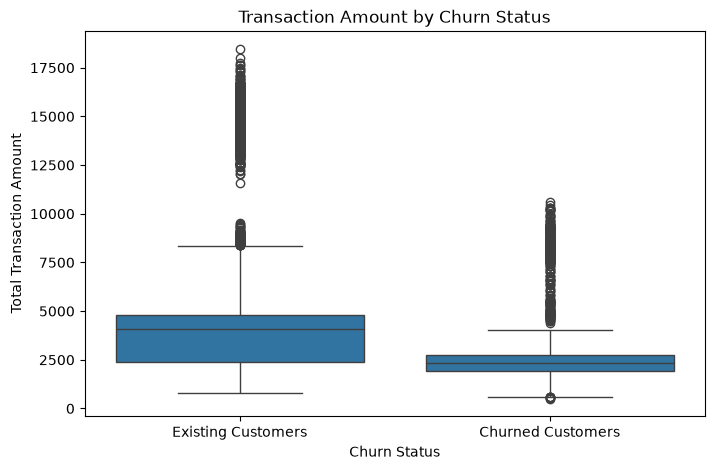

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Total_Trans_Amt"
)

plt.xticks([0, 1], ["Existing Customers", "Churned Customers"])
plt.title("Transaction Amount by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Transaction Amount")
plt.show()

In [19]:
existing = df[df["Churn"] == 0]["Total_Trans_Amt"]
churned = df[df["Churn"] == 1]["Total_Trans_Amt"]

t_stat, p_value = ttest_ind(churned, existing, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")


T-statistic: -22.686
P-value: 0.00000


### Interpretation

The statistical test shows a significant difference in total transaction amount between existing and churned customers (p < 0.05).

Churned customers have lower total transaction amounts than existing customers. Therefore, the null hypothesis (H0) is rejected in favour of the alternative hypothesis (H1).

### Hypothesis Outcome

The hypothesis is supported: lower transaction amounts are significantly associated with customer churn.

### Business Implication

Lower transaction activity may indicate customer disengagement. Customers with declining transaction amounts could therefore be monitored and targeted with appropriate retention strategies.


## Hypothesis 4. Credit Utilisation and Churn

**Business Question:**  
Is credit utilisation associated with customer churn?

**Feature:** `Avg_Utilization_Ratio`

**Null Hypothesis (H0):**  
There is no significant difference in average credit utilisation between existing and churned customers.

**Alternative Hypothesis (H1):**  
There is a significant difference in average credit utilisation between existing and churned customers.


In [20]:
df.groupby("Churn")["Avg_Utilization_Ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,8500.0,0.296412,0.272568,0.0,0.055,0.211,0.52925,0.994
1,1627.0,0.162475,0.264458,0.0,0.000,0.000,0.23100,0.999


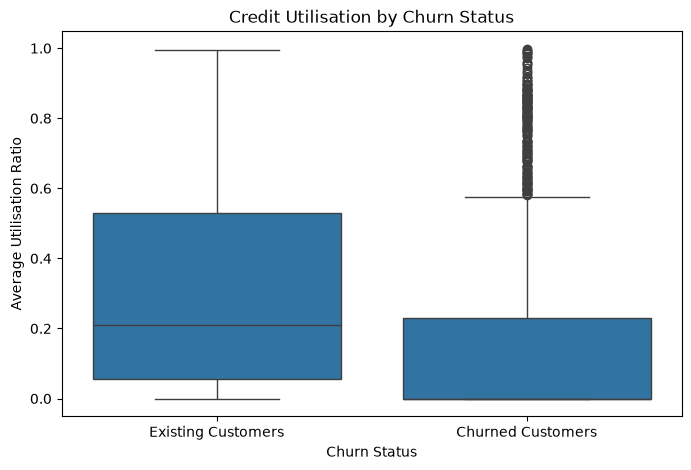

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Avg_Utilization_Ratio"
)

plt.xticks([0, 1], ["Existing Customers", "Churned Customers"])
plt.title("Credit Utilisation by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Utilisation Ratio")
plt.show()


In [22]:
existing = df[df["Churn"] == 0]["Avg_Utilization_Ratio"]
churned = df[df["Churn"] == 1]["Avg_Utilization_Ratio"]

t_stat, p_value = ttest_ind(churned, existing, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")


T-statistic: -18.623
P-value: 0.00000


### Hypothesis Outcome

The p-value is below 0.05, so the null hypothesis (H0) is rejected.

There is a statistically significant difference in credit utilisation between existing and churned customers. Churned customers show lower credit utilisation than existing customers.

### Business Implication

Lower credit utilisation may indicate reduced customer engagement with the bank's credit card. Customers with low utilisation could therefore be monitored as a potential churn-risk group, allowing the bank to take targeted retention actions.

---

# Section 5. Correlation Analysis

This section examines the relationships between numerical variables in the dataset using correlation analysis.

In [23]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
CLIENTNUM,1.000000,0.007613,0.006772,0.134588,0.006907,0.005729,0.005694,0.005708,0.000825,0.005633,0.017369,-0.019692,-0.002961,0.007696,0.000266,-0.046430
Customer_Age,0.007613,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114,0.018203
Dependent_count,0.006772,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,0.018991
Months_on_book,0.134588,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,0.013687
Total_Relationship_Count,0.006907,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.150005
Months_Inactive_12_mon,0.005729,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,0.152449
Contacts_Count_12_mon,0.005694,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,0.204491
Credit_Limit,0.005708,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,-0.023873
Total_Revolving_Bal,0.000825,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,-0.263053
Avg_Open_To_Buy,0.005633,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808,-0.000285


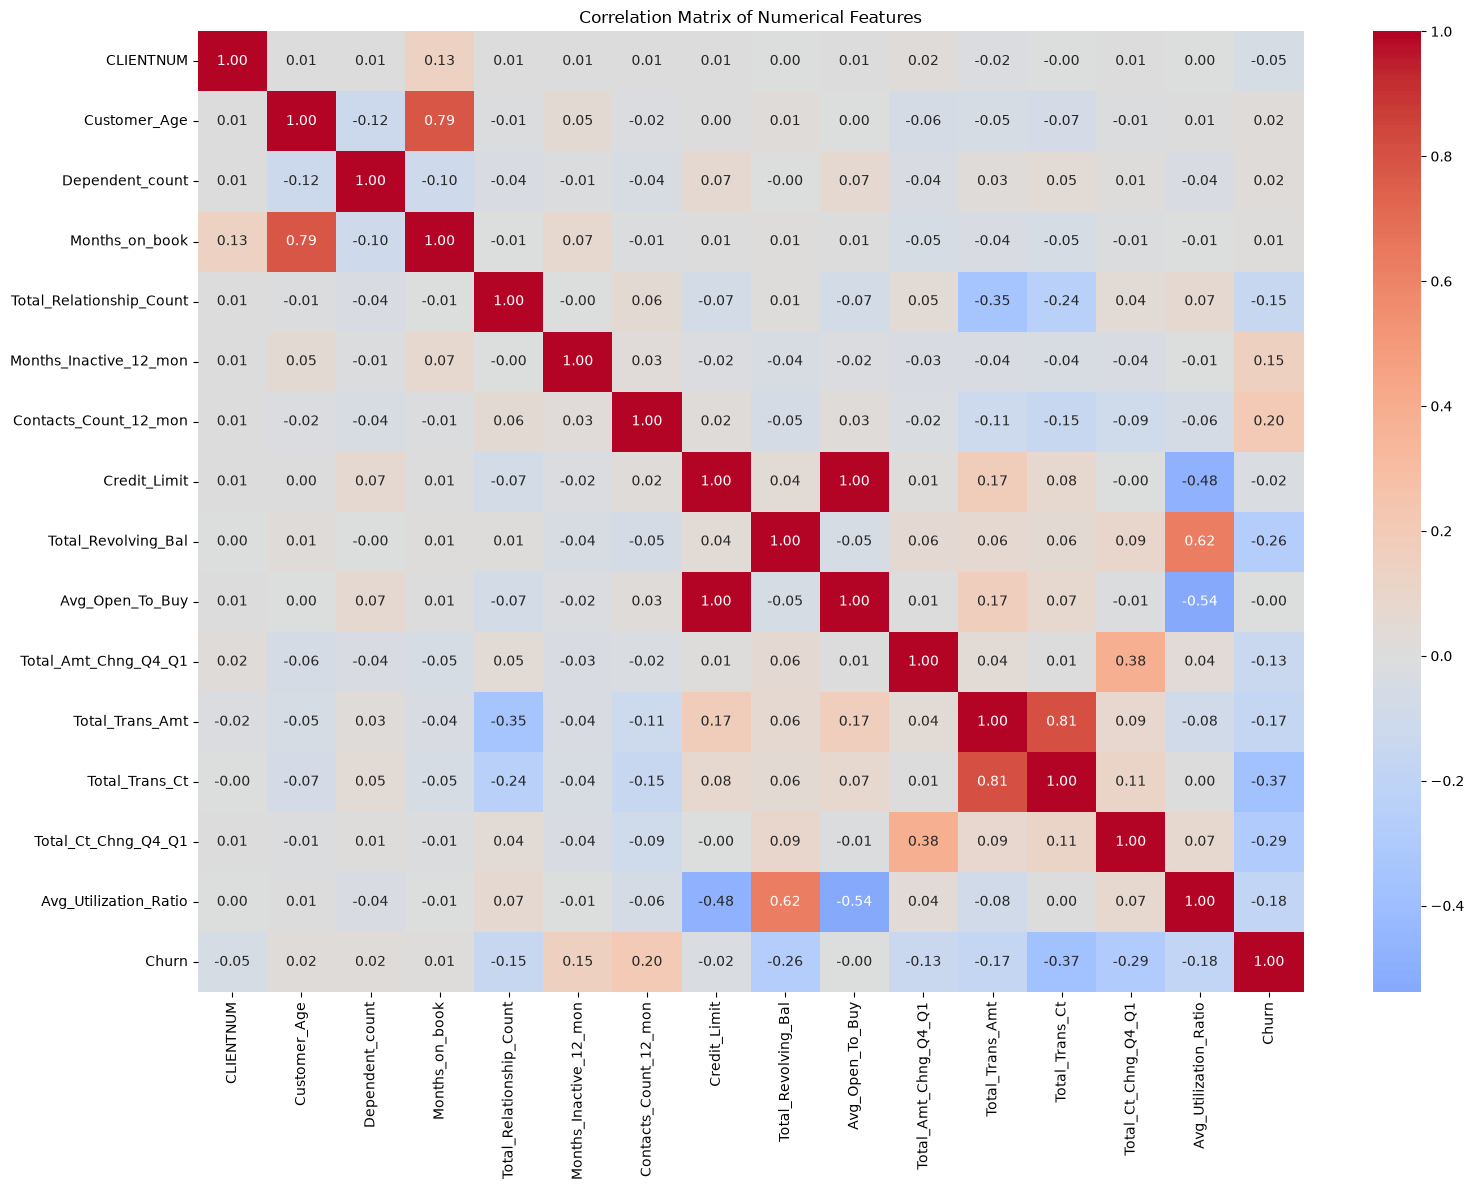

In [24]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


### Correlation Matrix Interpretation

The correlation analysis highlights several relationships between the numerical features in the dataset.

#### Strong Relationships

- `Credit_Limit` and `Avg_Open_To_Buy` show a very strong positive correlation.
- `Total_Trans_Amt` and `Total_Trans_Ct` have a strong positive correlation, indicating that customers who make more transactions also tend to have higher total transaction amounts.
- `Customer_Age` and `Months_on_book` also show a strong positive relationship.

#### Relationships with Churn

Among the numerical features, `Total_Trans_Ct` shows the strongest negative correlation with churn. This suggests that customers with higher transaction frequency are generally less likely to churn.

`Total_Ct_Chng_Q4_Q1` and `Total_Revolving_Bal` also show negative relationships with churn, while `Contacts_Count_12_mon` and `Months_Inactive_12_mon` show positive relationships.

These findings are consistent with the earlier hypothesis analysis, particularly the evidence that lower transaction activity and greater inactivity are associated with customer churn.

#### Implications for Predictive Modelling

The correlation analysis suggests that transaction behaviour, account activity and customer engagement may provide useful information for predicting churn.

Highly correlated predictors, such as `Credit_Limit` and `Avg_Open_To_Buy`, should also be considered carefully during model development because they may contain overlapping information.


---

## Section 6. Summary of EDA Findings

- Churn is associated with lower transaction activity and higher inactivity.
- Transaction frequency showed a strong relationship with churn.
- These findings can support churn prediction and customer retention strategies.